# Double distillation column: the infinite horizon vs the finite horizon

The model is the declared double column from [`models/double_column.py`](models/double_column.py):
two 41-tray columns in series separating a ternary mixture, the DAE example.
The weir flows, vapor compositions, tray temperatures, and purity aliases are
algebraic and undeclared; they ride along with the declared states. Two cases
of the same model. Case 1 runs five sampling steps with the infinite-horizon
terminal segment (`drto.infinite_horizon`,
[Dinh et al. 2025](https://doi.org/10.1016/j.jprocont.2025.103565)) carrying
the tail, which deactivates the declared terminal cost since the tail owns
the cost-to-go. Case 2 runs the full twenty-five step finite horizon with the
terminal cost live.

Both cases initialize before the solve (`initialize.py`): the states
interpolate linearly from the initial condition to the steady state, and
the algebraic and cost variables then come from their defining equations
at those states. A stand-in until initialization lands in drto.

## Case 1: five samples plus the infinite-horizon tail

In [1]:
import pyomo.environ as pyo
import drto
from models.double_column import double_column
from plotting import plot_states, plot_controls
from initialize import initialize_column
#import idaes
m1 = double_column(N=5)
pyo.TransformationFactory("dae.collocation").apply_to(m1, wrt=m1.t, nfe=5, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.infinite_horizon").apply_to(
    m1,
    nfe=3,                    # finite elements on the terminal segment
    ncp=5,                    # Gauss-Legendre points per element
    beta=1.2,                 # tail overestimation factor, > 1
    gamma="rule",             # the mesh rule, tanh(gamma*h) = tau_11; pass a number to override
    profile="collocation",    # segment control profile (pyomo-cvp)
)
pyo.TransformationFactory("drto.parameterize").apply_to(m1)  # the finite-horizon profiles
drto.build_objective(m1)
initialize_column(m1)
pyo.SolverFactory("pounce").solve(m1, tee=True)
#pyo.SolverFactory("ipopt").solve(m1, options={"linear_solver": "ma57"}, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmp_uv9o34n.pyomo.nl...
Parsed 26414 vars

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 26286, 'Number of variables': 26414, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 48.71845841407776}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  10  2.0215077e+02 3.42e+00 4.17e+03   -1.0 2.29e+01      - 7.26e-02 3.36e-01h  1


  11  2.0868174e+02 2.85e+00 3.39e+03   -1.0 1.69e+01      - 3.25e-01 1.89e-01h  1


  12  2.2564226e+02 2.13e+00 1.58e+03   -1.0 1.63e+01      - 7.09e-01 5.39e-01h  1


...

  42  2.1289888e+02 2.00e-13 1.14e-07   -5.7 6.14e-06      - 1.00e+00 1.00e+00h  1


  43  2.1289886e+02 3.21e-08 3.56e-02   -8.6 1.05e-03      - 1.00e+00 1.00e+00f  1


  44  2.1289886e+02 5.68e-14 3.67e-10   -8.6 7.58e-08      - 1.00e+00 1.00e+00h  1
pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmpra4z_0mb.pyomo.sol




Number of Iterations....: 44

                                   (scaled)                 (unscaled)
Objective...............:   2.1289885713353635e+02    2.1289885713353635e+02
Dual infeasibility......:   3.6664651126013784e-10    3.6664651126013784e-10
Constraint violation....:   5.6843418860808015e-14    5.6843418860808015e-14
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5059286046858150e-09    2.5059286046858150e-09
Overall NLP error.......:   2.5059286046858150e-09    2.5059286046858150e-09


Number of objective function evaluations             = 46
Number of objective gradient evaluations             = 46
Number of equality constraint evaluations            = 46
Number of inequality constraint evaluations          = 46
Number of equality constraint Jacobian evaluations   = 46
Number of inequality constraint Jacobian evaluations = 46
Number of Lagrangian Hessian evaluations             = 44
Total seconds in POUNCE    

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 26286, 'Number of variables': 26414, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 31.13477635383606}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [2]:
drto.info(m1)

<drto registry>
declarations:
  horizon: t (ContinuousSet, 16 points)
  states: x1 (free), x2 (free), M1 (free), M2 (free)
  dynamics: dM1[1,0]  ==  L1[2,0] - VB1[0] - B1[0]  for k in SetProduct_OrderedSet (shown at (1, 0))
  dynamics: dx1[1,1,0]  ==  (L1[2,0]*(x1[2,1,0] - x1[1,1,0]) - VB1[0]*(y1[1,1,0] - x1[1,1,0]))/M1[1,0]  for k in SetProduct_OrderedSet (shown at (1, 1, 0))
  dynamics: dM2[1,0]  ==  L2[2,0] - VB2[0] - B2[0]  for k in SetProduct_OrderedSet (shown at (1, 0))
  dynamics: dx2[1,1,0]  ==  (L2[2,0]*(x2[2,1,0] - x2[1,1,0]) - VB2[0]*(y2[1,1,0] - x2[1,1,0]))/M2[1,0]  for k in SetProduct_OrderedSet (shown at (1, 1, 0))
  controls: LT1 (piecewise_constant, free), VB1 (piecewise_constant, free), D1 (piecewise_constant, free), B1 (piecewise_constant, free), LT2 (piecewise_constant, free), VB2 (piecewise_constant, free), D2 (piecewise_constant, free), B2 (piecewise_constant, free)
  tracking stage cost: cost[k]  ==  (LT1[k] - LT1_ss)**2 + (VB1[k] - VB1_ss)**2 + (D1[k] - D1_ss)**2 + (B1[k] - B1_ss)**2 + (LT2[k] - LT2_ss)**2 + (VB2[k] - VB2_ss)**2 + (D2[k] - D2_ss)**2 + (B2[k] - B2_ss)**2 + 10*(SUM((x1[_2,_3,k] - x1_ss[_2,_3])**2 + (x2[_2,_3,k] - x2_ss[_2,_3])**2 for _2 in tray for _3 in comp) + SUM((M1[_4,k] - M1_ss[_4])**2 + (M2[_4,k] - M2_ss[_4])**2 for _4 in tray))  for k in OrderedScalarSet
  terminal cost: term  ==  10*((x1[1,1,5] - x1_ss[1,1])**2 + (x2[1,1,5] - x2_ss[1,1])**2 + (x1[1,2,5] - x1_ss[1,2])**2 + (x2[1,2,5] - x2_ss[1,2])**2 + (x1[2,1,5] - x1_ss[2,1])**2 + (x2[2,1,5] - x2_ss[2,1])**2 + (x1[2,2,5] - x1_ss[2,2])**2 + (x2[2,2,5] - x2_ss[2,2])**2 + (x1[3,1,5] - x1_ss[3,1])**2 + (x2[3,1,5] - x2_ss[3,1])**2 + (x1[3,2,5] - x1_ss[3,2])**2 + (x2[3,2,5] - x2_ss[3,2])**2 + (x1[4,1,5] - x1_ss[4,1])**2 + (x2[4,1,5] - x2_ss[4,1])**2 + (x1[4,2,5] - x1_ss[4,2])**2 + (x2[4,2,5] - x2_ss[4,2])**2 + (x1[5,1,5] - x1_ss[5,1])**2 + (x2[5,1,5] - x2_ss[5,1])**2 + (x1[5,2,5] - x1_ss[5,2])**2 + (x2[5,2,5] - x2_ss[5,2])**2 + (x1[6,1,5] - x1_ss[6,1])**2 + (x2[6,1,5] - x2_ss[6,1])**2 + (x1[6,2,5] - x1_ss[6,2])**2 + (x2[6,2,5] - x2_ss[6,2])**2 + (x1[7,1,5] - x1_ss[7,1])**2 + (x2[7,1,5] - x2_ss[7,1])**2 + (x1[7,2,5] - x1_ss[7,2])**2 + (x2[7,2,5] - x2_ss[7,2])**2 + (x1[8,1,5] - x1_ss[8,1])**2 + (x2[8,1,5] - x2_ss[8,1])**2 + (x1[8,2,5] - x1_ss[8,2])**2 + (x2[8,2,5] - x2_ss[8,2])**2 + (x1[9,1,5] - x1_ss[9,1])**2 + (x2[9,1,5] - x2_ss[9,1])**2 + (x1[9,2,5] - x1_ss[9,2])**2 + (x2[9,2,5] - x2_ss[9,2])**2 + (x1[10,1,5] - x1_ss[10,1])**2 + (x2[10,1,5] - x2_ss[10,1])**2 + (x1[10,2,5] - x1_ss[10,2])**2 + (x2[10,2,5] - x2_ss[10,2])**2 + (x1[11,1,5] - x1_ss[11,1])**2 + (x2[11,1,5] - x2_ss[11,1])**2 + (x1[11,2,5] - x1_ss[11,2])**2 + (x2[11,2,5] - x2_ss[11,2])**2 + (x1[12,1,5] - x1_ss[12,1])**2 + (x2[12,1,5] - x2_ss[12,1])**2 + (x1[12,2,5] - x1_ss[12,2])**2 + (x2[12,2,5] - x2_ss[12,2])**2 + (x1[13,1,5] - x1_ss[13,1])**2 + (x2[13,1,5] - x2_ss[13,1])**2 + (x1[13,2,5] - x1_ss[13,2])**2 + (x2[13,2,5] - x2_ss[13,2])**2 + (x1[14,1,5] - x1_ss[14,1])**2 + (x2[14,1,5] - x2_ss[14,1])**2 + (x1[14,2,5] - x1_ss[14,2])**2 + (x2[14,2,5] - x2_ss[14,2])**2 + (x1[15,1,5] - x1_ss[15,1])**2 + (x2[15,1,5] - x2_ss[15,1])**2 + (x1[15,2,5] - x1_ss[15,2])**2 + (x2[15,2,5] - x2_ss[15,2])**2 + (x1[16,1,5] - x1_ss[16,1])**2 + (x2[16,1,5] - x2_ss[16,1])**2 + (x1[16,2,5] - x1_ss[16,2])**2 + (x2[16,2,5] - x2_ss[16,2])**2 + (x1[17,1,5] - x1_ss[17,1])**2 + (x2[17,1,5] - x2_ss[17,1])**2 + (x1[17,2,5] - x1_ss[17,2])**2 + (x2[17,2,5] - x2_ss[17,2])**2 + (x1[18,1,5] - x1_ss[18,1])**2 + (x2[18,1,5] - x2_ss[18,1])**2 + (x1[18,2,5] - x1_ss[18,2])**2 + (x2[18,2,5] - x2_ss[18,2])**2 + (x1[19,1,5] - x1_ss[19,1])**2 + (x2[19,1,5] - x2_ss[19,1])**2 + (x1[19,2,5] - x1_ss[19,2])**2 + (x2[19,2,5] - x2_ss[19,2])**2 + (x1[20,1,5] - x1_ss[20,1])**2 + (x2[20,1,5] - x2_ss[20,1])**2 + (x1[20,2,5] - x1_ss[20,2])**2 + (x2[20,2,5] - x2_ss[20,2])**2 + (x1[21,1,5] - x1_ss[21,1])**2 + (x2[21,1,5] - x2_ss[21,1])**2 + (x1[21,2,5] - x1_ss[21,2])**2 + (x2[21,2,5] - x2_ss[21,2])**2 + (x1[22,1,5] - x1_ss[22,1])**2 + 

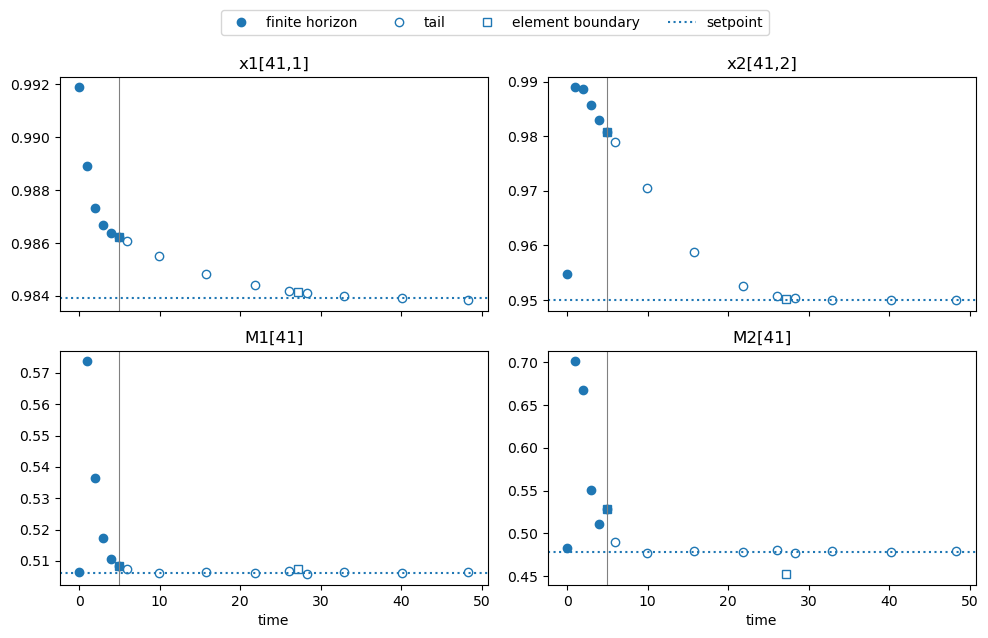

In [3]:
# multi-index states select by member: overhead purities and condenser holdups
plot_states(m1, states=["x1[41,1]", "x2[41,2]", "M1[41]", "M2[41]"]);

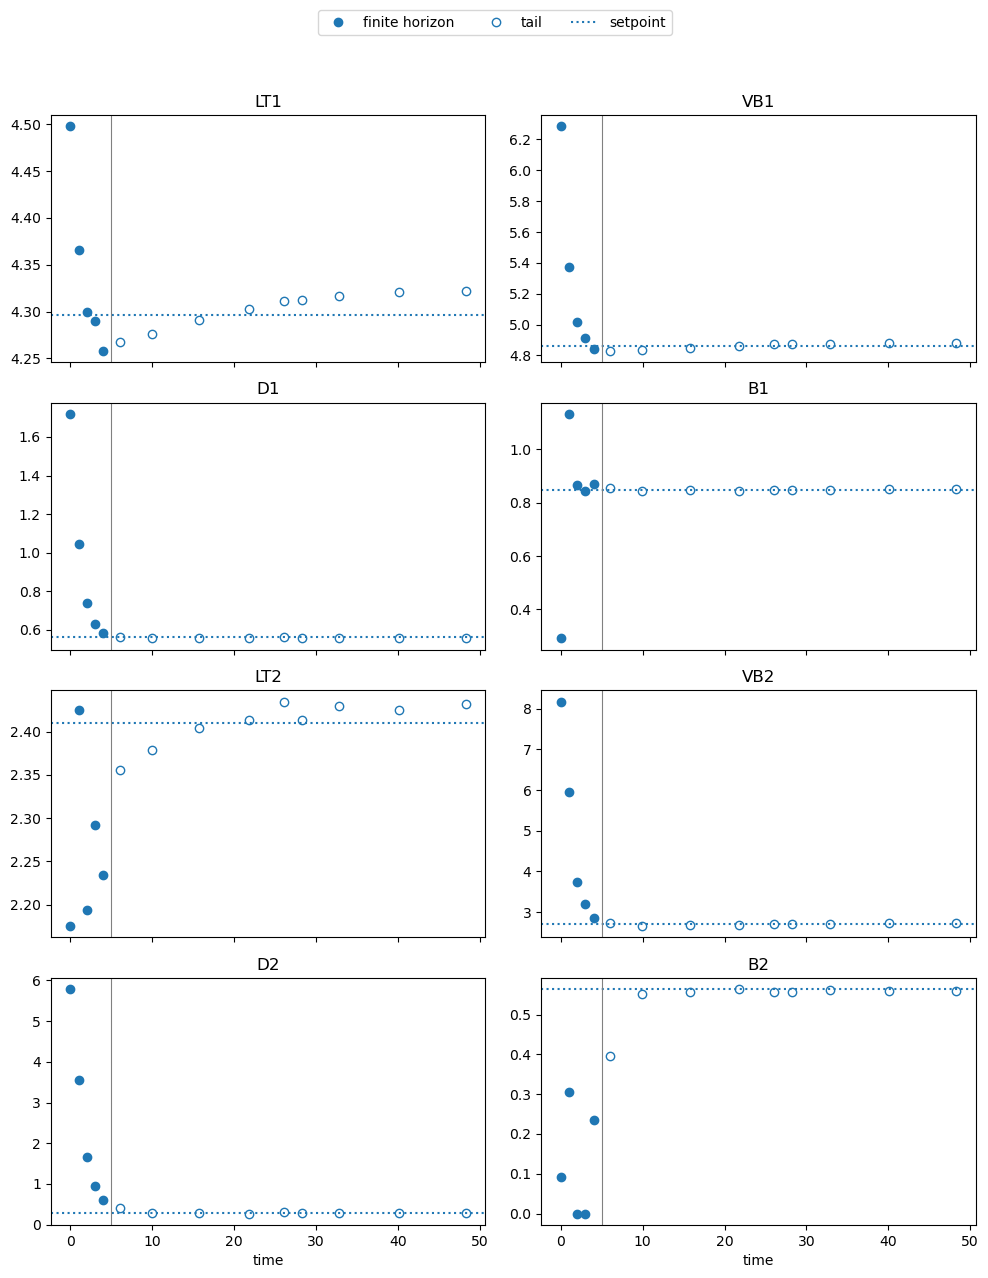

In [4]:
plot_controls(m1);

## Case 2: twenty-five samples, finite horizon with the terminal cost

In [5]:
m2 = double_column(N=25)
pyo.TransformationFactory("dae.collocation").apply_to(m2, wrt=m2.t, nfe=25, ncp=3, scheme="LAGRANGE-RADAU")
pyo.TransformationFactory("drto.parameterize").apply_to(m2)
drto.build_objective(m2)
initialize_column(m2)
pyo.SolverFactory("pounce").solve(m2, tee=True)
#pyo.SolverFactory("ipopt").solve(m2, options={"linear_solver": "ma57"}, tee=True)

********************************************************************************

                    ####    ###   /   # /#   #/  ####  #####
                    #   #  #   # /#   #/ ##  /  #      #
                    ####   #   #/ #   /  # #/#  #      ####
                    #      #   /  #  /#  # /##  #      #
                    #       ##/    #/#   #/  #   ####  #####

********************************************************************************
This program contains POUNCE, a pure-Rust interior-point optimization solver
for nonlinear, conic, and global problems (its NLP core is ported from Ipopt).
Released under the Eclipse Public License (EPL) â€” drop-in compatible with Ipopt.
         For more information visit https://github.com/jkitchin/pounce
********************************************************************************

This is POUNCE version 0.8.0, running with linear solver FERAL.

Reading C:\Users\Devin\AppData\Local\Temp\tmpq4yu5_ow.pyomo.nl...
Parsed 62166 vars

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 61966, 'Number of variables': 62166, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 384.28442192077637}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

   6  6.4205269e+02 2.71e+00 8.73e+02   -1.0 3.34e+01      - 1.10e-01 1.47e-01h  1


   7  6.7388262e+02 2.63e+00 6.35e+02   -1.0 3.68e+01      - 2.18e-01 1.06e-01h  1


   8  7.2957324e+02 2.78e+00 5.13e+02   -1.0 3.89e+01      - 1.89e-01 1.83e-01h  1


...

  88  2.0881656e+02 8.12e-14 4.76e-09   -5.7 5.64e-07      - 1.00e+00 1.00e+00h  1


  89  2.0881655e+02 4.67e-08 7.98e-02   -8.6 5.57e-04      - 9.99e-01 1.00e+00h  1


iter      objective   inf_pr   inf_du lg(mu)    ||d|| lg(rg) alpha_du alpha_pr  ls
  90  2.0881655e+02 5.68e-14 6.65e-11   -8.6 5.14e-08      - 1.00e+00 1.00e+00h  1
pounce: wrote C:\Users\Devin\AppData\Local\Temp\tmpo74jjve6.pyomo.sol




Number of Iterations....: 90

                                   (scaled)                 (unscaled)
Objective...............:   2.0881655256813397e+02    2.0881655256813397e+02
Dual infeasibility......:   6.6523971665388368e-11    6.6523971665388368e-11
Constraint violation....:   5.6843418860808015e-14    5.6843418860808015e-14
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5059041974283520e-09    2.5059041974283520e-09
Overall NLP error.......:   2.5059041974283520e-09    2.5059041974283520e-09


Number of objective function evaluations             = 104
Number of objective gradient evaluations             = 92
Number of equality constraint evaluations            = 104
Number of inequality constraint evaluations          = 104
Number of equality constraint Jacobian evaluations   = 92
Number of inequality constraint Jacobian evaluations = 92
Number of Lagrangian Hessian evaluations             = 90
Total seconds in POUNCE 

{'Problem': [{'Lower bound': -inf, 'Upper bound': inf, 'Number of objectives': 1, 'Number of constraints': 61966, 'Number of variables': 62166, 'Sense': 'unknown'}], 'Solver': [{'Status': 'ok', 'Message': 'POUNCE 0.8.0\\x3a SolveSucceeded', 'Termination condition': 'optimal', 'Id': 0, 'Error rc': 0, 'Time': 229.31943106651306}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [6]:
drto.info(m2)

<drto registry>
declarations:
  horizon: t (ContinuousSet, 76 points)
  states: x1 (free), x2 (free), M1 (free), M2 (free)
  dynamics: dM1[1,0]  ==  L1[2,0] - VB1[0] - B1[0]  for k in SetProduct_OrderedSet (shown at (1, 0))
  dynamics: dx1[1,1,0]  ==  (L1[2,0]*(x1[2,1,0] - x1[1,1,0]) - VB1[0]*(y1[1,1,0] - x1[1,1,0]))/M1[1,0]  for k in SetProduct_OrderedSet (shown at (1, 1, 0))
  dynamics: dM2[1,0]  ==  L2[2,0] - VB2[0] - B2[0]  for k in SetProduct_OrderedSet (shown at (1, 0))
  dynamics: dx2[1,1,0]  ==  (L2[2,0]*(x2[2,1,0] - x2[1,1,0]) - VB2[0]*(y2[1,1,0] - x2[1,1,0]))/M2[1,0]  for k in SetProduct_OrderedSet (shown at (1, 1, 0))
  controls: LT1 (piecewise_constant, free), VB1 (piecewise_constant, free), D1 (piecewise_constant, free), B1 (piecewise_constant, free), LT2 (piecewise_constant, free), VB2 (piecewise_constant, free), D2 (piecewise_constant, free), B2 (piecewise_constant, free)
  tracking stage cost: cost[k]  ==  (LT1[k] - LT1_ss)**2 + (VB1[k] - VB1_ss)**2 + (D1[k] - D1_ss)**2 + (B1[k] - B1_ss)**2 + (LT2[k] - LT2_ss)**2 + (VB2[k] - VB2_ss)**2 + (D2[k] - D2_ss)**2 + (B2[k] - B2_ss)**2 + 10*(SUM((x1[_2,_3,k] - x1_ss[_2,_3])**2 + (x2[_2,_3,k] - x2_ss[_2,_3])**2 for _2 in tray for _3 in comp) + SUM((M1[_4,k] - M1_ss[_4])**2 + (M2[_4,k] - M2_ss[_4])**2 for _4 in tray))  for k in OrderedScalarSet
  terminal cost: term  ==  10*((x1[1,1,25] - x1_ss[1,1])**2 + (x2[1,1,25] - x2_ss[1,1])**2 + (x1[1,2,25] - x1_ss[1,2])**2 + (x2[1,2,25] - x2_ss[1,2])**2 + (x1[2,1,25] - x1_ss[2,1])**2 + (x2[2,1,25] - x2_ss[2,1])**2 + (x1[2,2,25] - x1_ss[2,2])**2 + (x2[2,2,25] - x2_ss[2,2])**2 + (x1[3,1,25] - x1_ss[3,1])**2 + (x2[3,1,25] - x2_ss[3,1])**2 + (x1[3,2,25] - x1_ss[3,2])**2 + (x2[3,2,25] - x2_ss[3,2])**2 + (x1[4,1,25] - x1_ss[4,1])**2 + (x2[4,1,25] - x2_ss[4,1])**2 + (x1[4,2,25] - x1_ss[4,2])**2 + (x2[4,2,25] - x2_ss[4,2])**2 + (x1[5,1,25] - x1_ss[5,1])**2 + (x2[5,1,25] - x2_ss[5,1])**2 + (x1[5,2,25] - x1_ss[5,2])**2 + (x2[5,2,25] - x2_ss[5,2])**2 + (x1[6,1,25] - x1_ss[6,1])**2 + (x2[6,1,25] - x2_ss[6,1])**2 + (x1[6,2,25] - x1_ss[6,2])**2 + (x2[6,2,25] - x2_ss[6,2])**2 + (x1[7,1,25] - x1_ss[7,1])**2 + (x2[7,1,25] - x2_ss[7,1])**2 + (x1[7,2,25] - x1_ss[7,2])**2 + (x2[7,2,25] - x2_ss[7,2])**2 + (x1[8,1,25] - x1_ss[8,1])**2 + (x2[8,1,25] - x2_ss[8,1])**2 + (x1[8,2,25] - x1_ss[8,2])**2 + (x2[8,2,25] - x2_ss[8,2])**2 + (x1[9,1,25] - x1_ss[9,1])**2 + (x2[9,1,25] - x2_ss[9,1])**2 + (x1[9,2,25] - x1_ss[9,2])**2 + (x2[9,2,25] - x2_ss[9,2])**2 + (x1[10,1,25] - x1_ss[10,1])**2 + (x2[10,1,25] - x2_ss[10,1])**2 + (x1[10,2,25] - x1_ss[10,2])**2 + (x2[10,2,25] - x2_ss[10,2])**2 + (x1[11,1,25] - x1_ss[11,1])**2 + (x2[11,1,25] - x2_ss[11,1])**2 + (x1[11,2,25] - x1_ss[11,2])**2 + (x2[11,2,25] - x2_ss[11,2])**2 + (x1[12,1,25] - x1_ss[12,1])**2 + (x2[12,1,25] - x2_ss[12,1])**2 + (x1[12,2,25] - x1_ss[12,2])**2 + (x2[12,2,25] - x2_ss[12,2])**2 + (x1[13,1,25] - x1_ss[13,1])**2 + (x2[13,1,25] - x2_ss[13,1])**2 + (x1[13,2,25] - x1_ss[13,2])**2 + (x2[13,2,25] - x2_ss[13,2])**2 + (x1[14,1,25] - x1_ss[14,1])**2 + (x2[14,1,25] - x2_ss[14,1])**2 + (x1[14,2,25] - x1_ss[14,2])**2 + (x2[14,2,25] - x2_ss[14,2])**2 + (x1[15,1,25] - x1_ss[15,1])**2 + (x2[15,1,25] - x2_ss[15,1])**2 + (x1[15,2,25] - x1_ss[15,2])**2 + (x2[15,2,25] - x2_ss[15,2])**2 + (x1[16,1,25] - x1_ss[16,1])**2 + (x2[16,1,25] - x2_ss[16,1])**2 + (x1[16,2,25] - x1_ss[16,2])**2 + (x2[16,2,25] - x2_ss[16,2])**2 + (x1[17,1,25] - x1_ss[17,1])**2 + (x2[17,1,25] - x2_ss[17,1])**2 + (x1[17,2,25] - x1_ss[17,2])**2 + (x2[17,2,25] - x2_ss[17,2])**2 + (x1[18,1,25] - x1_ss[18,1])**2 + (x2[18,1,25] - x2_ss[18,1])**2 + (x1[18,2,25] - x1_ss[18,2])**2 + (x2[18,2,25] - x2_ss[18,2])**2 + (x1[19,1,25] - x1_ss[19,1])**2 + (x2[19,1,25] - x2_ss[19,1])**2 + (x1[19,2,25] - x1_ss[19,2])**2 + (x2[19,2,25] - x2_ss[19,2])**2 + (x1[20,1,25] - x1_ss[20,1])**2 + (x2[20,1,25] - x2_ss[20,1])**2 + (x1[20,2,25] - x1_ss[20,2])**2 + (x2[20,2,25] - x2_ss[20,2])**2 + (x1[21,1,25] - x1_ss[21,1])**2 + (x2[21,1,25] - x2_ss[21,1])**2 + (x1[21,2,25] -

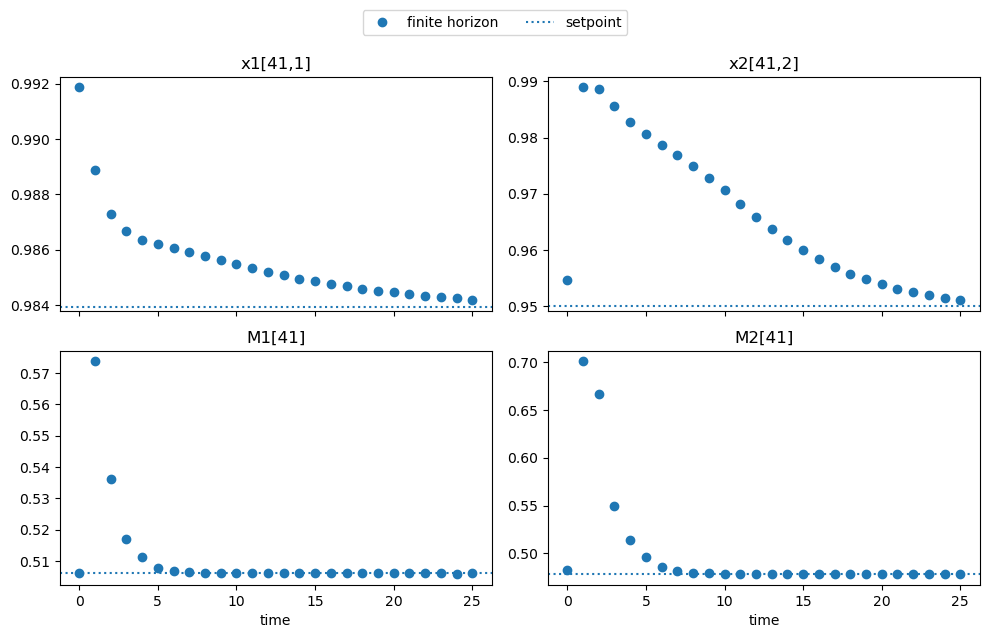

In [7]:
plot_states(m2, states=["x1[41,1]", "x2[41,2]", "M1[41]", "M2[41]"]);

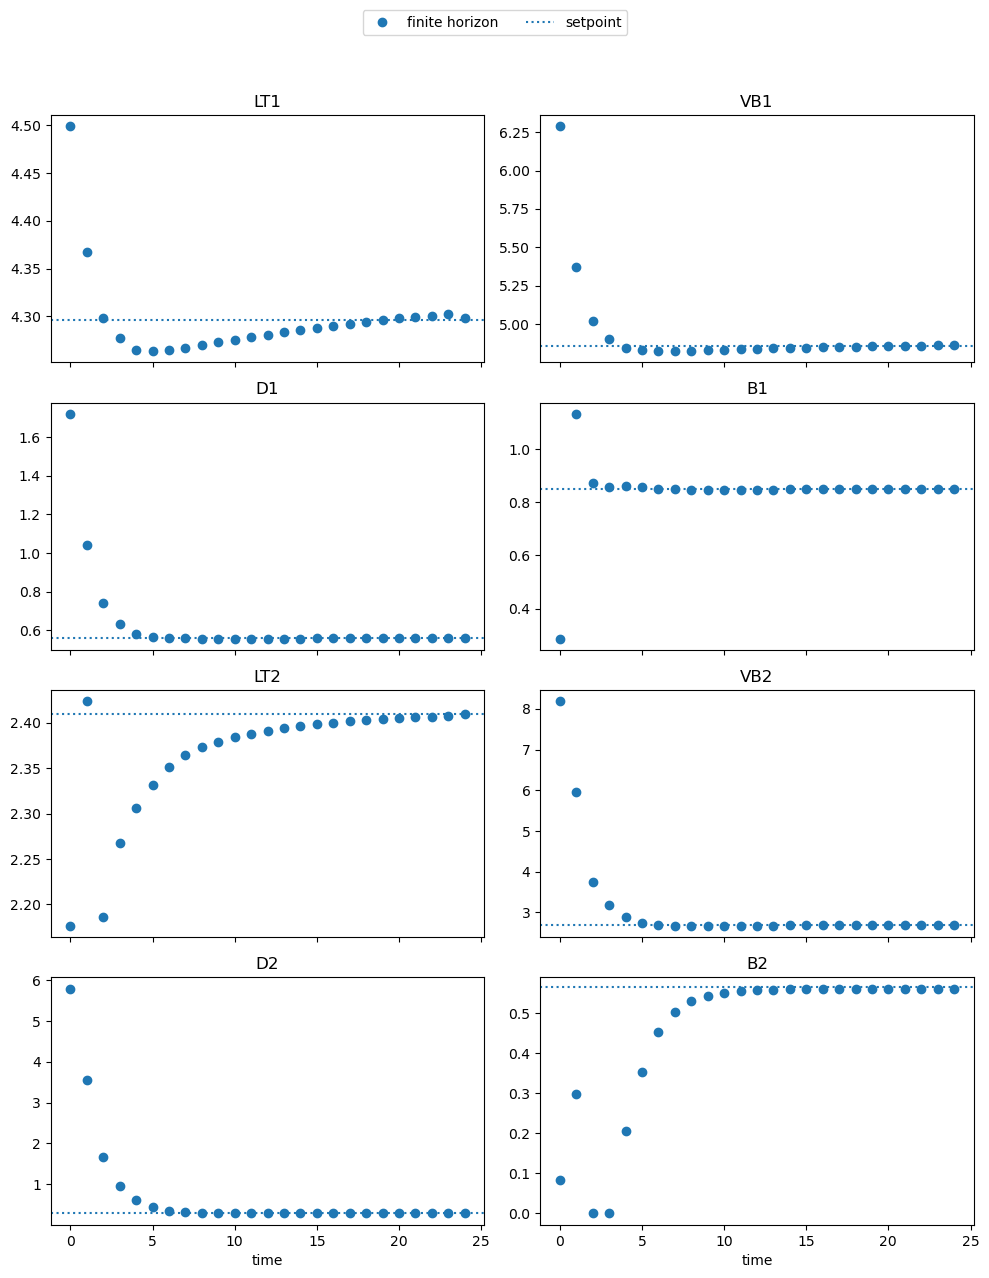

In [8]:
plot_controls(m2);